# 动态中断
- 在运行时调用interrupt()中断
- interrupt是靠抛出`GraphInterrupt`异常实现中断，所以不能将interrupt写在try里
- 不能将interrupt放在条件判断或者不稳定的循环中，不能随意打乱节点中的interrupt的顺序，因为每个interrupt恢复时，都会从头到尾执行节点，而不是精确的从阻断的地方恢复，且多个interrupt串行时，会记录interrupt的顺序，每次resume都会按顺序恢复interrupt,且已经恢复的interrupt不会再次执行，如果在恢复时，状态或者打乱了interrupt的顺序，值就会发生错乱,具体见案例《在条件中设置interrupt且恢复时状态变化》,其中第2次执行赋值年龄时，由于Command(update=)修改了状态，因此恢复时不会再执行年龄的interrupt,而是执行gender的interrupt,导致年龄赋值给了性别，即便多恢复一次，由于已恢复的interrupt不会再执行，再次输入male，也不会再次赋值给性别
- 实现中断的前提，必须有checkpointer记录状态图
- 也由于有多个interrupt时，会从头开始执行node，因此node里的副作用必须保证幂等性;即便没有多个interrupt串行，如果业务逻辑写在interrupt前面也要保证幂等性，在首次调用时也会执行node，恢复时会再执行一次(或者将副作用放在interrupt之后，或者将副作用和中断抽取到2个节点，进行隔离)
- 在节点中使用`interrupt(value)`等待输入,value可作为给用户的中断提示,value可以是任意可被JSON序列化的值,如果value中包含不能序列化的内容，会报：`TypeError: Type is not msgpack serializable: Interrupt`
- `graph.invoke()`会获取到一个中断的响应`interrupt_res`，可以通过`interrupt_res['__interrupt__'][0].value`获取中断提示,`interrupt_res['__interrupt__']`是一个list，当并行中断时，我们可以遍历这个list,获取id,构建一个key为id，value为用户输入的dict给Command的resume参数,来同时恢复多个并行中断点
- `graph.invoke(Commnad(resume=username))` 将resume的作为interrupt的响应，并且恢复中断
- 中断的检查点特征：
    - StateSnapshot的interrupts: 记录了当前超步发生的所有中断，如果有多个并行中断，会汇总记录到interrupts中，如果是串行多个，后者覆盖前者
    - StateSnapshot的tasks的PregelTask实例的interrupts记录了当前任务触发的中断信息, 如果有多个并行中断，会有多个PregelTask，如果是串行多个，后者覆盖前者

## 基础HITL中断



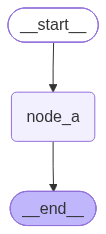

{'__interrupt__': [Interrupt(value='请输入您的姓名', id='5007d10cf536e1086c5d4ddc51300a3d')]}
请输入您的姓名
{'username': '你好'}


In [3]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


#1. 声明状态
class OverAllState(TypedDict):
    username: str


#2. 声明节点
def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

#4. 想要使用中断 => 必须配置检查点
# checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display

display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupt_res = graph.invoke({}, config=config)
print(interrupt_res)

prompt = interrupt_res['__interrupt__'][0].value
print(prompt)
username = input(prompt)
# 5. 恢复图的中断执行
resume_res = graph.invoke(Command(resume=username), config=config)
print(resume_res)

## 并行中断


In [24]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄")
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

history = list(graph.get_state_history(config=config))
rprint(history)

# 构建 中断ID -> 恢复指令 的映射
resume_map = {}
for i in interrupted_res['__interrupt__']:
    user_input = input(f"{i.value}: ")
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resumed_res = graph.invoke(Command(resume=resume_map), config=config)
print('=' * 30, '-> resumed_res <-', '=' * 30)
print(resumed_res)

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

============================== -> interrupt_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的姓名', id='dfeb4cbf171d1b505e7bafb88bc23bce'), Interrupt(value='请输入您的年龄', id='96b8c7c72e4db86bc571329704b5070f')]}


[
    StateSnapshot(
        values={},
        next=('node_a', 'node_b'),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1970b3-935d-61e8-8000-d92ad4252d81'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-13T11:36:28.545876+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1970b3-9353-6559-bfff-89eaa4a88289'
            }
        },
        tasks=(
            PregelTask(
                id='dae23711-4bc4-3faa-cacb-57b306c993e8',
                name='node_a',
                path=('__pregel_pull', 'node_a'),
                error=None,
                interrupts=(Interrupt(value='请输入您的姓名', id='dfeb4cbf171d1b505e7bafb88bc23bce'),),
                state=None,
                result=None
            ),
            PregelTask(
                id='3bda6df0-7663-38aa-78ae-890ff02961db',
                name='node_b',
                path=('__pregel_pull', 'node_b'),
                error=None,
                interrupts=(Interrupt(value='请输入您的年龄', id='96b8c7c72e4db86bc571329704b5070f'),),
                state=None,
                result=None
            )
        ),
        interrupts=(
            Interrupt(value='请输入您的姓名', id='dfeb4cbf171d1b505e7bafb88bc23bce'),
            Interrupt(value='请输入您的年龄', id='96b8c7c72e4db86bc571329704b5070f')
        )
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f1970b3-9353-6559-bfff-89eaa4a88289'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-13T11:36:28.541868+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='157f7949-d9b1-284c-aa4d-a6f9ddc21567',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

============================== -> resumed_res <- ==============================
{'username': 'wanggx', 'age': 1}


## 审批模式

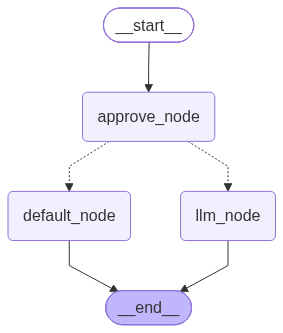

{'topic': '菊花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='2780e894604881177c88c817e57760b9')]}
{'topic': '菊花', 'poem': '请求被拒绝', 'is_approved': False}
{'topic': '牡丹花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='30ba805f5d8409eddadb9ed43bdf4591')]}
{'topic': '牡丹花', 'poem': '国色天香冠群芳，\n春风拂面露华光。\n姚黄魏紫争娇艳，\n独占花王第一香。', 'is_approved': True}


In [6]:
from time import sleep
from typing import TypedDict, Literal

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain_deepseek import ChatDeepSeek

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

#1. 声明状态
class OverAllState(TypedDict):
    topic:str
    poem:str
    is_approved:bool

#2. 声明节点
def approve_node(state:OverAllState) -> Command[Literal["llm_node","default_node"]]:
    is_approved = interrupt("是否同意调用模型?")
    goto = "llm_node" if is_approved else "default_node"
    return Command(
        goto=goto,
        update={"is_approved":is_approved}
    )

def llm_node(state:OverAllState) -> OverAllState:
    topic = state["topic"]
    res = model.invoke([HumanMessage(content=f"帮我写一首关于{topic}主题的七言绝句,只写诗句,不需要赏析")]).content

    return {
        "poem":res
    }

def default_node(state:OverAllState) -> OverAllState:
    return {
        "poem":"请求被拒绝"
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)

builder.add_node("approve_node",approve_node)
builder.add_node("llm_node",llm_node)
builder.add_node("default_node",default_node)
builder.add_edge(START,"approve_node")
builder.add_edge("llm_node",END)
builder.add_edge("default_node",END)

#4. 添加检查点后端
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

#5. 首次执行 -> 触发中断
config = {"configurable":{"thread_id":"234"}}
interrupt_res = graph.invoke({"topic":"菊花"},config=config)
print(interrupt_res)
#6. 人工审核
user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'
# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config)
print(approved_res)

#7. 审核不通过
config1 = {"configurable":{"thread_id":"456"}}
interrupt_res = graph.invoke({"topic":"牡丹花"},config=config1)
print(interrupt_res)

user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'
# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config1)
print(approved_res)

## 审核与编辑模式

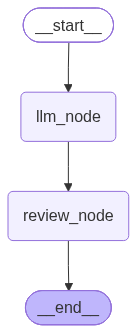

============================== -> interrupt_res <- ==============================
{'topic': '布偶猫', 'poem': '蓝眸似海雪毛鲜，\n玉爪轻移步若仙。\n软若轻云慵入抱，\n娇憨常伴主人眠。', '__interrupt__': [Interrupt(value={'instruction': '请审核并修改大模型生成的七言绝句', 'poem': '蓝眸似海雪毛鲜，\n玉爪轻移步若仙。\n软若轻云慵入抱，\n娇憨常伴主人眠。'}, id='2565b1446c456279f9c2bf8712341955')]}
原始诗句：
蓝眸似海雪毛鲜，
玉爪轻移步若仙。
软若轻云慵入抱，
娇憨常伴主人眠。
============================== -> reviewed_res <- ==============================
{'topic': '布偶猫', 'poem': '蓝眸似海雪毛鲜，\n玉爪轻移步若仙。\n软若轻云慵入抱，\n娇憨常伴主人眠。', 'reviewed_poem': '天天向上'}


In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    reviewed_poem: str

def llm_node(state: OverAllState) -> OverAllState:
    topic = state['topic']

    res = model.invoke([HumanMessage(content=f"帮我写一首关于 {topic} 的七言绝句，只给出诗句，不要赏析")]).content
    return {
        "poem": res
    }

def review_node(state: OverAllState) -> OverAllState:
    reviewed_poem = interrupt({
        "instruction": "请审核并修改大模型生成的七言绝句",
        "poem": state['poem']
    })
    return {
        "reviewed_poem": reviewed_poem
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("llm_node", llm_node)
builder.add_node("review_node", review_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "review_node")
builder.add_edge("review_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "review_test"}}
interrupted_res = graph.invoke({"topic": "布偶猫"}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

print("原始诗句：")
print(interrupted_res['__interrupt__'][0].value['poem'])
user_review = input("请审核并修改诗句（直接回车保留原诗）: ")
if not user_review.strip():
    user_review = interrupted_res['__interrupt__'][0].value['poem']
reviewed_res = graph.invoke(Command(resume=user_review), config=config)
print('=' * 30, '-> reviewed_res <-', '=' * 30)
print(reviewed_res)

## 工具执行审批模式

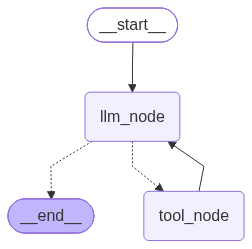

2026-08-13 16:54:34.752 | INFO     | __main__:tool_node:57 - 工具 get_weather 被调用, 对应的 tool_call: {'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_966c54d6e58a46828b1227c6', 'type': 'tool_call'}


============================== -> interrupt_res <- ==============================
================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================

我来帮您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_966c54d6e58a46828b1227c6)
 Call ID: call_966c54d6e58a46828b1227c6
  Args:
    city: 北京
============================== -> interrupt_info <- ==============================
[Interrupt(value={'action': 'get_weather', 'question': '是否同意查询天气？'}, id='ba5f0ab219d71316124b047f9c221ab0')]


2026-08-13 16:54:40.151 | INFO     | __main__:tool_node:57 - 工具 get_weather 被调用, 对应的 tool_call: {'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_966c54d6e58a46828b1227c6', 'type': 'tool_call'}
2026-08-13 16:54:40.153 | INFO     | __main__:get_weather:27 - is_approved: True


============================== -> approved_res <- ==============================
================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================

我来帮您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_966c54d6e58a46828b1227c6)
 Call ID: call_966c54d6e58a46828b1227c6
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

根据查询结果，北京今天天气不错！如果您需要了解更详细的天气信息（如温度、湿度、风力等），建议您查看专业的天气预报应用或网站获取更全面的数据。


In [8]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from common import init_simple_dashscope_model

from loguru import logger
from dotenv import load_dotenv
load_dotenv(override=True)

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    查询指定城市的当日天气

    Args:
        city: 城市名称
    """
    is_approved = interrupt({
        "action": "get_weather",
        "question": "是否同意查询天气？"
    })

    logger.info("is_approved: {}", is_approved)
    if is_approved:
        return f"{city} 今天天气不错"
    else:
        return "用户拒绝查询天气"

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

tools_by_name = {"get_weather": get_weather}

model_with_tools = model.bind_tools([get_weather])

def llm_node(state: MessagesState) -> MessagesState:
    messages = state['messages']
    response = model_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

def tool_node(state: MessagesState) -> MessagesState:
    last_msg = state['messages'][-1]

    tool_msgs = []
    for tool_call in last_msg.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        logger.info("工具 {} 被调用, 对应的 tool_call: {}", tool_call["name"], tool_call)
        tool_res = tool.invoke(tool_call["args"])
        tool_msg = ToolMessage(
            name = tool_call["name"],
            content = tool_res,
            tool_call_id = tool_call["id"]
        )
        tool_msgs.append(tool_msg)

    return {
        "messages": tool_msgs
    }

def router(state: MessagesState) -> Literal["tool_node", END]:
    if state['messages'][-1].tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "llm_node")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "tool_test"}}
interrupted_res = graph.invoke({"messages": [HumanMessage("今天北京天气如何？")]}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
for msg in interrupted_res['messages']:
    msg.pretty_print()
print('=' * 30, '-> interrupt_info <-', '=' * 30)
print(interrupted_res['__interrupt__'])

user_approved = input("是否同意查询天气？(y/n): ").strip().lower() == 'y'
approved_res = graph.invoke(Command(resume=user_approved), config=config)
print('=' * 30, '-> approved_res <-', '=' * 30)
for msg in approved_res['messages']:
    msg.pretty_print()

## 单节点串行中断模式

In [15]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from rich import print as rprint

class OverAllState(TypedDict):
    username: str # 姓名
    age: int # 年龄
    gender: Literal["male", "female"] # 性别

def get_info_node(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的用户名：")
    print('======用户名', username)
    age = interrupt("请输入您的年龄：")
    print('======年龄', age)
    gender = interrupt("请输入您的性别：(male/female)")
    print('======性别', age)

    return {
        "username": username,
        "age": age,
        "gender": gender
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("get_info_node", get_info_node)
builder.add_edge(START, "get_info_node")
builder.add_edge("get_info_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "seq_interrupt_test"}}
username_interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> username_interrupted_res <-', '=' * 30)
print(username_interrupted_res)

history = list(graph.get_state_history(config=config))
print('一')
rprint(history)

user_name = input("请输入您的用户名：")
age_interrupted_res = graph.invoke(Command(resume=user_name), config=config)
print('=' * 30, '-> age_interrupted_res <-', '=' * 30)
print(age_interrupted_res)

history = list(graph.get_state_history(config=config))
print('二')
rprint(history)

user_age = input("请输入您的年龄：")
gender_interrupted_res = graph.invoke(Command(resume=int(user_age)), config=config)
print('=' * 30, '-> gender_interrupted_res <-', '=' * 30)
print(gender_interrupted_res)

history = list(graph.get_state_history(config=config))
print('三')
rprint(history)

user_gender = input("请输入您的性别：(male/female): ")
resumed_res = graph.invoke(Command(resume=user_gender), config=config)
print('=' * 30, '-> resumed_res <-', '=' * 30)
print(resumed_res)

history = list(graph.get_state_history(config=config))
print('四')
rprint(history)

============================== -> username_interrupted_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的用户名：', id='5ce61374efaebfedce749050bb1b0810')]}
一


[
    StateSnapshot(
        values={},
        next=('get_info_node',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b3-6a45-8000-168443ac90d9'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-13T09:33:45.270934+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        tasks=(
            PregelTask(
                id='0e259f04-e766-d356-0d07-9a4035f7c869',
                name='get_info_node',
                path=('__pregel_pull', 'get_info_node'),
                error=None,
                interrupts=(Interrupt(value='请输入您的用户名：', id='5ce61374efaebfedce749050bb1b0810'),),
                state=None,
                result=None
            ),
        ),
        interrupts=(Interrupt(value='请输入您的用户名：', id='5ce61374efaebfedce749050bb1b0810'),)
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-13T09:33:45.270029+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='e42121c6-d54a-0002-4dcc-68a63b890c54',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

======用户名 1
============================== -> age_interrupted_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的年龄：', id='5ce61374efaebfedce749050bb1b0810')]}
二


[
    StateSnapshot(
        values={},
        next=('get_info_node',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b3-6a45-8000-168443ac90d9'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-13T09:33:45.270934+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        tasks=(
            PregelTask(
                id='0e259f04-e766-d356-0d07-9a4035f7c869',
                name='get_info_node',
                path=('__pregel_pull', 'get_info_node'),
                error=None,
                interrupts=(Interrupt(value='请输入您的年龄：', id='5ce61374efaebfedce749050bb1b0810'),),
                state=None,
                result={}
            ),
        ),
        interrupts=(Interrupt(value='请输入您的年龄：', id='5ce61374efaebfedce749050bb1b0810'),)
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-13T09:33:45.270029+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='e42121c6-d54a-0002-4dcc-68a63b890c54',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

======用户名 1
======年龄 2
============================== -> gender_interrupted_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的性别：(male/female)', id='5ce61374efaebfedce749050bb1b0810')]}
三


[
    StateSnapshot(
        values={},
        next=('get_info_node',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b3-6a45-8000-168443ac90d9'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-13T09:33:45.270934+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        tasks=(
            PregelTask(
                id='0e259f04-e766-d356-0d07-9a4035f7c869',
                name='get_info_node',
                path=('__pregel_pull', 'get_info_node'),
                error=None,
                interrupts=(
                    Interrupt(value='请输入您的性别：(male/female)', id='5ce61374efaebfedce749050bb1b0810'),
                ),
                state=None,
                result={}
            ),
        ),
        interrupts=(Interrupt(value='请输入您的性别：(male/female)', id='5ce61374efaebfedce749050bb1b0810'),)
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-13T09:33:45.270029+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='e42121c6-d54a-0002-4dcc-68a63b890c54',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

======用户名 1
======年龄 2
======性别 2
============================== -> resumed_res <- ==============================
{'username': '1', 'age': 2, 'gender': '3'}
四


[
    StateSnapshot(
        values={'username': '1', 'age': 2, 'gender': '3'},
        next=(),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-7434-6f9d-8001-05ca9eee6115'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-08-13T09:33:50.147356+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b3-6a45-8000-168443ac90d9'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={},
        next=('get_info_node',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b3-6a45-8000-168443ac90d9'
            }
        },
        metadata={'source': 'loop', 'step': 0, 'parents': {}},
        created_at='2026-08-13T09:33:45.270934+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        tasks=(
            PregelTask(
                id='0e259f04-e766-d356-0d07-9a4035f7c869',
                name='get_info_node',
                path=('__pregel_pull', 'get_info_node'),
                error=None,
                interrupts=(
                    Interrupt(value='请输入您的性别：(male/female)', id='5ce61374efaebfedce749050bb1b0810'),
                ),
                state=None,
                result={'username': '1', 'age': 2, 'gender': '3'}
            ),
        ),
        interrupts=(Interrupt(value='请输入您的性别：(male/female)', id='5ce61374efaebfedce749050bb1b0810'),)
    ),
    StateSnapshot(
        values={},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'seq_interrupt_test',
                'checkpoint_ns': '',
                'checkpoint_id': '1f196fa1-45b1-66bf-bfff-4440dbb3af6e'
            }
        },
        metadata={'source': 'input', 'step': -1, 'parents': {}},
        created_at='2026-08-13T09:33:45.270029+00:00',
        parent_config=None,
        tasks=(
            PregelTask(
                id='e42121c6-d54a-0002-4dcc-68a63b890c54',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    )
]

## 在条件中设置interrupt且恢复时状态变化

In [23]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from rich import print as rprint

class OverAllState(TypedDict):
    username: str # 姓名
    age: int # 年龄
    gender: Literal["male", "female"] # 性别
    verify_age: str

def get_info_node(state: OverAllState) -> OverAllState:
    print('get_info_node执行开始')
    username = interrupt("请输入您的用户名：")
    print('======用户名', username)
    age = None
    if state.get('verify_age', '') == 'y':
        age = interrupt("请输入您的年龄：")
        print('======年龄', age)
    gender = interrupt("请输入您的性别：(male/female)")
    print('======性别', gender)

    return {
        "username": username,
        "age":  age,
        "gender": gender
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("get_info_node", get_info_node)
builder.add_edge(START, "get_info_node")
builder.add_edge("get_info_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "seq_interrupt_test"}}
username_interrupted_res = graph.invoke({
    "verify_age": 'y'
}, config=config)
print('=' * 30, '-> username_interrupted_res <-', '=' * 30)
print(username_interrupted_res)

history = list(graph.get_state_history(config=config))
# print('一')
# rprint(history)

user_name = input("请输入您的用户名：")
age_interrupted_res = graph.invoke(Command(resume=user_name), config=config)
print('=' * 30, '-> age_interrupted_res <-', '=' * 30)
print(age_interrupted_res)

history = list(graph.get_state_history(config=config))
# print('二')
# rprint(history)

user_age = input("请输入您的年龄：")
gender_interrupted_res = graph.invoke(Command(
    resume=int(user_age),
    update={
        "verify_age": 'n'
    }
), config=config)
# 由于改变了verify_age，age的interrupt不会执行，只需要恢复2次就可以得到node的响应,后面第三次恢复是多余
print('=' * 30, '-> gender_interrupted_res <-', '=' * 30)
print(gender_interrupted_res)

history = list(graph.get_state_history(config=config))
# print('三')
# rprint(history)

user_gender = input("请输入您的性别：(male/female): ")
resumed_res = graph.invoke(Command(resume=user_gender), config=config)
print('=' * 30, '-> resumed_res <-', '=' * 30)
print(resumed_res)

history = list(graph.get_state_history(config=config))
# print('四')
# rprint(history)

get_info_node执行开始
============================== -> username_interrupted_res <- ==============================
{'verify_age': 'y', '__interrupt__': [Interrupt(value='请输入您的用户名：', id='14ce56ec60f62af4bbe1765330a59edd')]}
get_info_node执行开始
======用户名 1
============================== -> age_interrupted_res <- ==============================
{'verify_age': 'y', '__interrupt__': [Interrupt(value='请输入您的年龄：', id='14ce56ec60f62af4bbe1765330a59edd')]}
get_info_node执行开始
======用户名 1
======性别 2
============================== -> gender_interrupted_res <- ==============================
{'username': '1', 'age': None, 'gender': 2, 'verify_age': 'n'}
============================== -> resumed_res <- ==============================
{'username': '1', 'age': None, 'gender': 2, 'verify_age': 'n'}
